# GNN Training

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

from gnn_project.config import Config
from gnn_project.training.train_utils import train_or_load_model, load_data

## GNN Model

In [2]:
from pathlib import Path

config = Config(
    ml_data_dir=Path('..').resolve() / 'data',
    experiment_name='gnn_peak8day',
    scenario_names={'manhattan_case_study': [
        'gnn_peak_2018-11-11', 'gnn_peak_2018-11-12', 'gnn_peak_2018-11-13', 'gnn_peak_2018-11-14',
        'gnn_peak_2018-11-15', 'gnn_peak_2018-11-17',  # val
        'gnn_peak_2018-11-16', 'gnn_peak_2018-11-18',  # test
    ]},
    train_ratio=0.5, val_ratio=0.25, test_ratio=0.25,
    sim_start=25200, sim_end=36000, sim_step=30,
    load_saved_model=True,
    overwrite_data=False,
    recompute_norm_stats=False,
    log_level='INFO',
)

In [3]:
import logging
logging.basicConfig(level=config.log_level)

In [4]:
data, masks = load_data(config)

/Users/hoda_hamdy/Documents/02_Research/Projects/fleetpy/FleetPy/gnn_project/dataloaders/gnn_dataloader.py:128: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  train_graphs = 

/Users/hoda_hamdy/Documents/02_Research/Projects/fleetpy/FleetPy/gnn_project/dataloaders/gnn_dataloader.py:129: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  val_graphs = to

/Users/hoda_hamdy/Documents/02_Research/Projects/fleetpy/FleetPy/gnn_project/dataloaders/gnn_dataloader.py:130: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_graphs = t

## Feature Names
Access feature names for analysis

In [5]:
from gnn_project.training.train_utils import load_feature_names

# Load feature names for the current experiment
feature_names = load_feature_names(config)

# Display feature names for each node/edge type
for key, names in feature_names.items():
    print(f"\n{key}: {len(names)} features")
    print(names[:5] if len(names) > 5 else names)  # Show first 5 features


request: 41 features
['clustering_coeff', 'd_lat', 'd_lon', 'demand_supply_ratio', 'direct_td']

vehicle: 22 features
['clustering_coeff', 'in_degree', 'in_degree_from_requests', 'lat', 'lon']

request__connects__request: 69 features
['avg_detour_distance', 'avg_detour_ratio', 'avg_shared_ride_time', 'avg_time_detour', 'avg_time_detour_ratio']

vehicle__connects__request: 45 features
['arrival_slack', 'assigned_max_pooling_score', 'assigned_mean_pooling_score', 'assigned_min_max_detour_ratio', 'assigned_overlap_count']


In [6]:
model, trainer = train_or_load_model(config, data, masks)

INFO:gnn_project.training.train_utils:Loading model from /Users/hoda_hamdy/Documents/02_Research/Projects/fleetpy/FleetPy/gnn_project/data/models/gnn_peak8day/best_model.pt


## Visualization

In [7]:
logging.basicConfig(level='INFO')

In [8]:
from gnn_project.analysis.plots import visualize_graph
from gnn_project.training.train_utils import get_edge_predictions
from gnn_project.defaults import *

scenario = 6  # index into config.scenario_names['manhattan_case_study'] - 6 = gnn_peak_2018-11-16 (test)
scenario_sizes = [360] * 8  # each scenario covers the 7-10am peak window at 30s steps
scenario_start_idx = sum(scenario_sizes[:scenario])


Edge from v134 to r82: score=0.63, is_true=False, type=VR
Edge from v99 to r82: score=0.46, is_true=False, type=VR
Edge from v89 to r82: score=0.46, is_true=False, type=VR
Edge from v4 to r82: score=0.40, is_true=False, type=VR
Edge from v144 to r82: score=0.39, is_true=False, type=VR
Edge from v323 to r115: score=0.65, is_true=True, type=VR
Edge from v59 to r115: score=0.61, is_true=False, type=VR
Edge from v47 to r115: score=0.60, is_true=False, type=VR
Edge from v219 to r115: score=0.52, is_true=False, type=VR
Edge from v263 to r115: score=0.49, is_true=False, type=VR
Edge from v320 to r119: score=0.76, is_true=False, type=VR
Edge from v318 to r119: score=0.72, is_true=True, type=VR
Edge from v193 to r119: score=0.69, is_true=False, type=VR
Edge from v240 to r119: score=0.49, is_true=False, type=VR
Edge from v304 to r119: score=0.43, is_true=False, type=VR


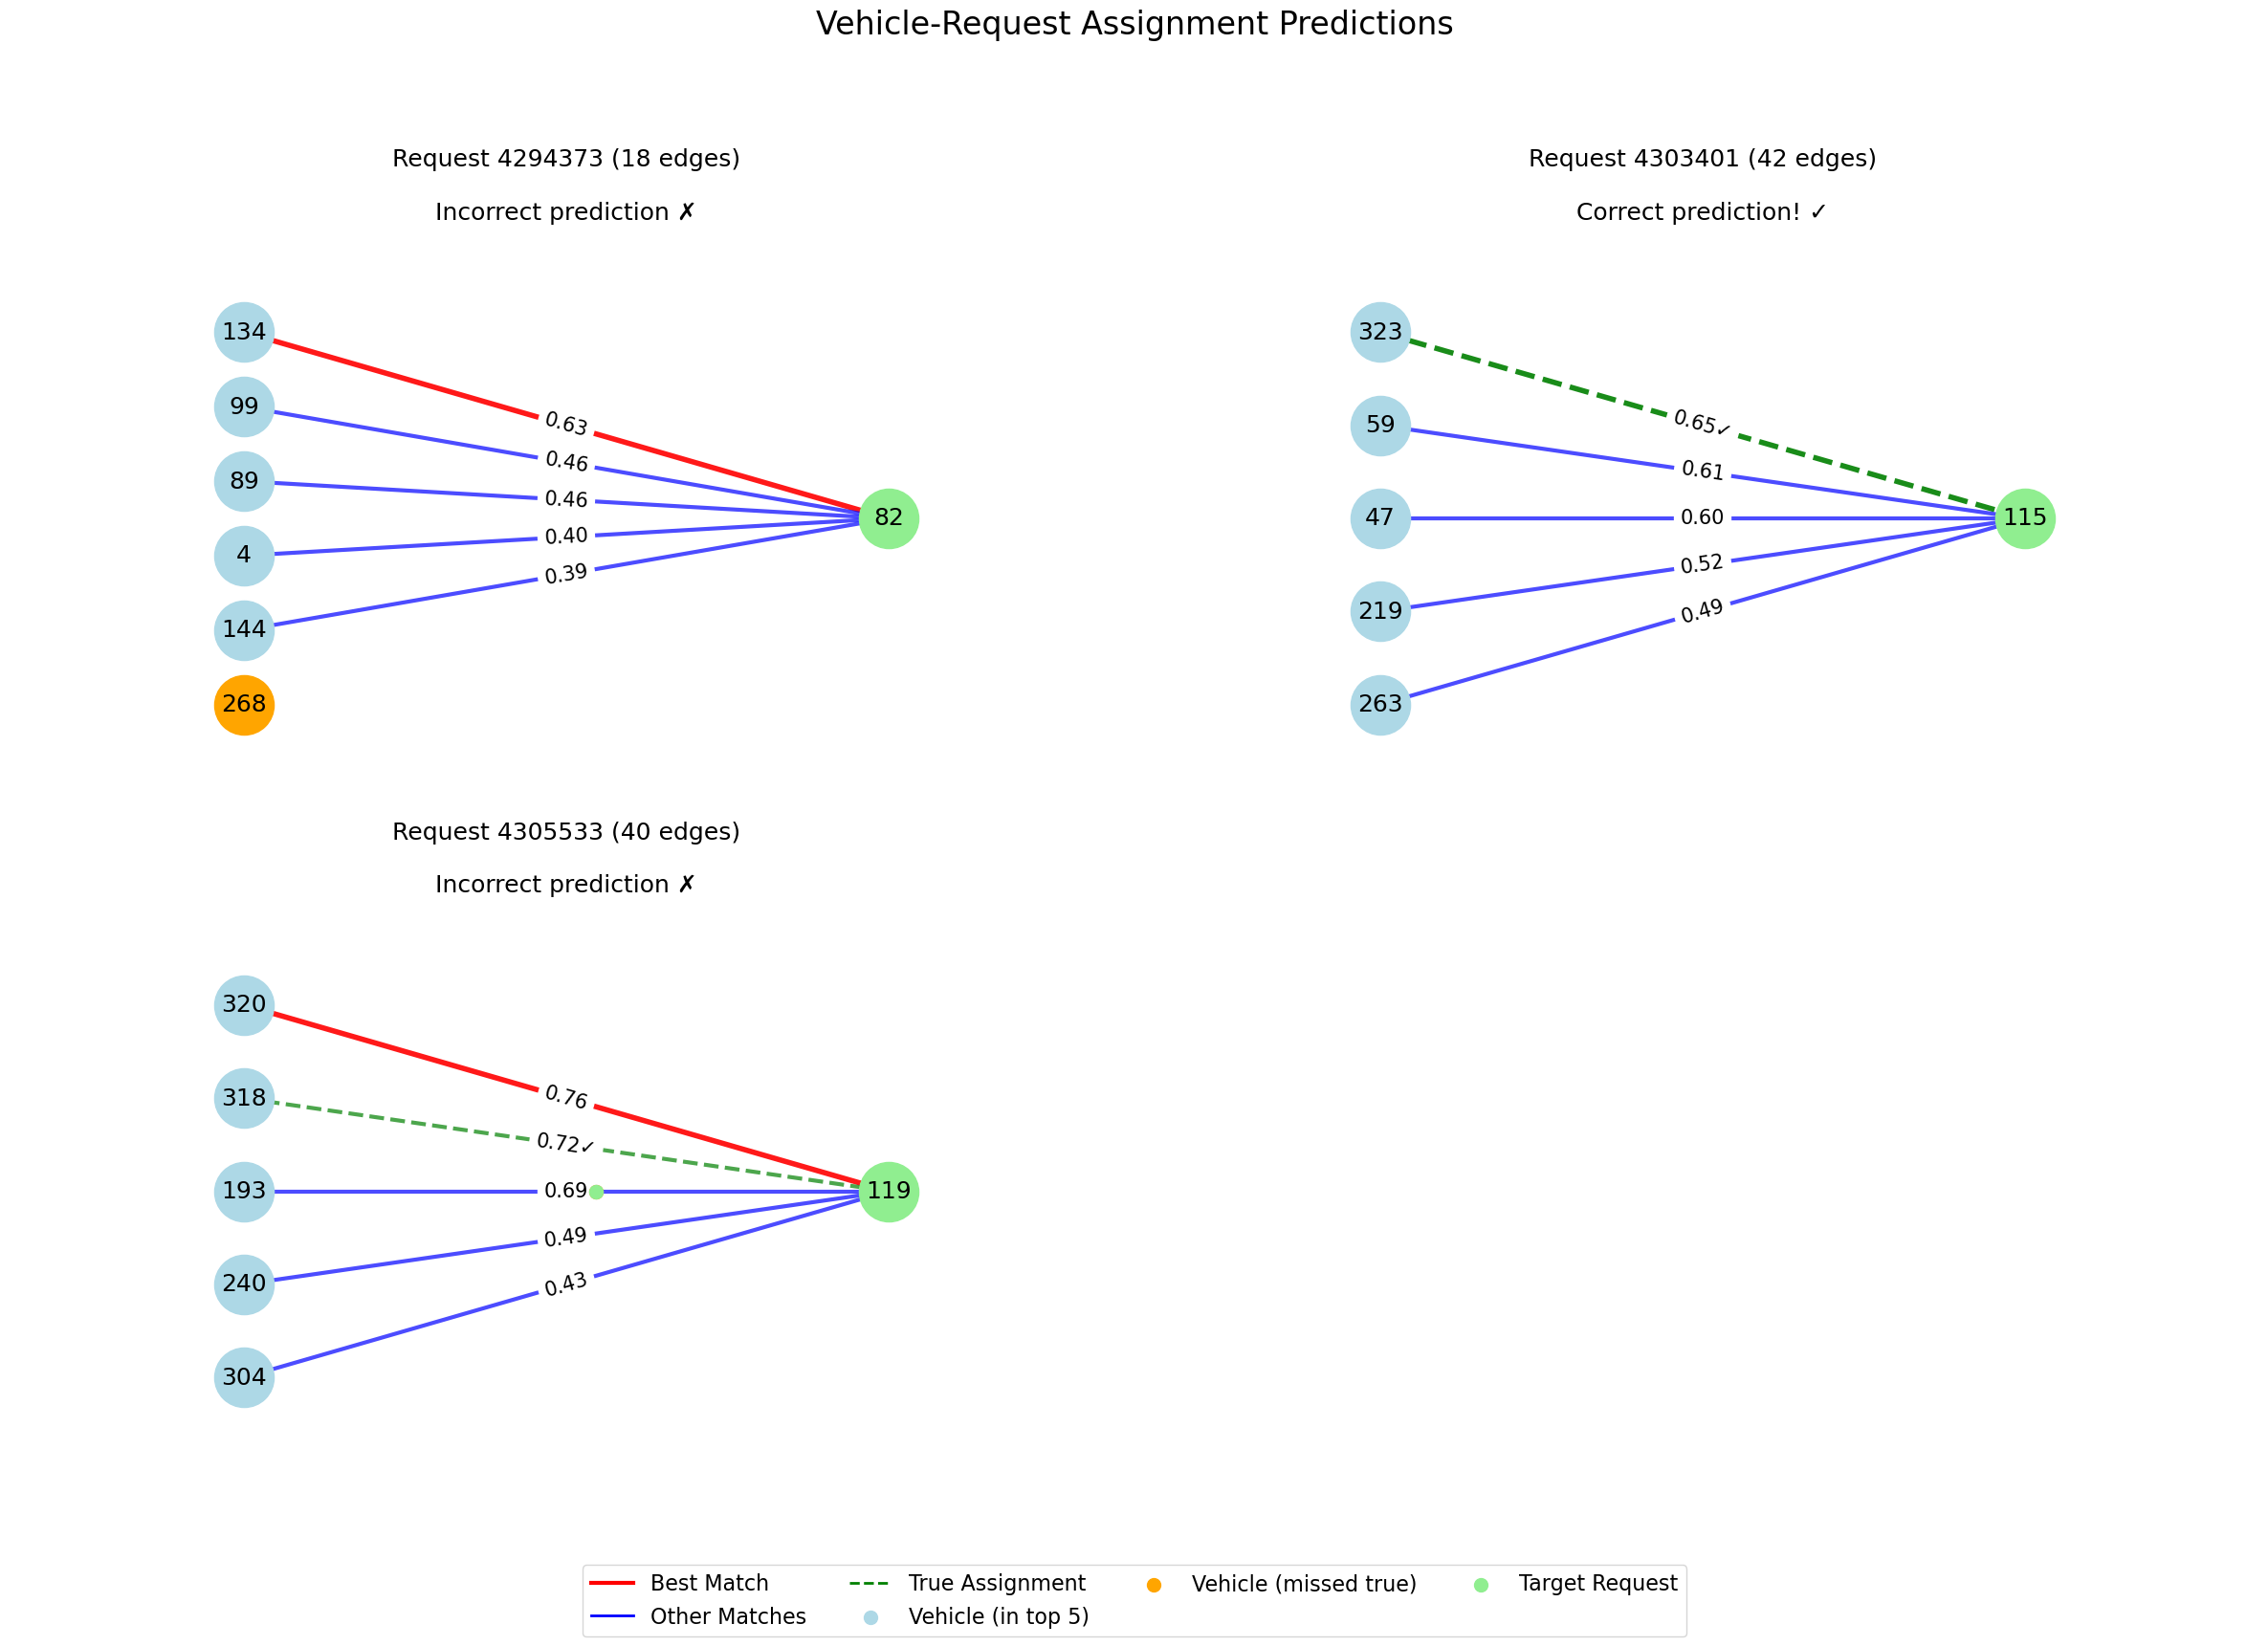

In [9]:
graph_idx = scenario_start_idx + 12  # 12 timesteps into the chosen scenario
predictions = get_edge_predictions(data[graph_idx], model, device='cpu')
edge_types = [VR_EDGE_NAME]
visualize_graph(data, graph_idx=graph_idx, predictions=predictions, edge_types=edge_types, scenario_start_idx=scenario_start_idx);

=== 2018-11-16 ===


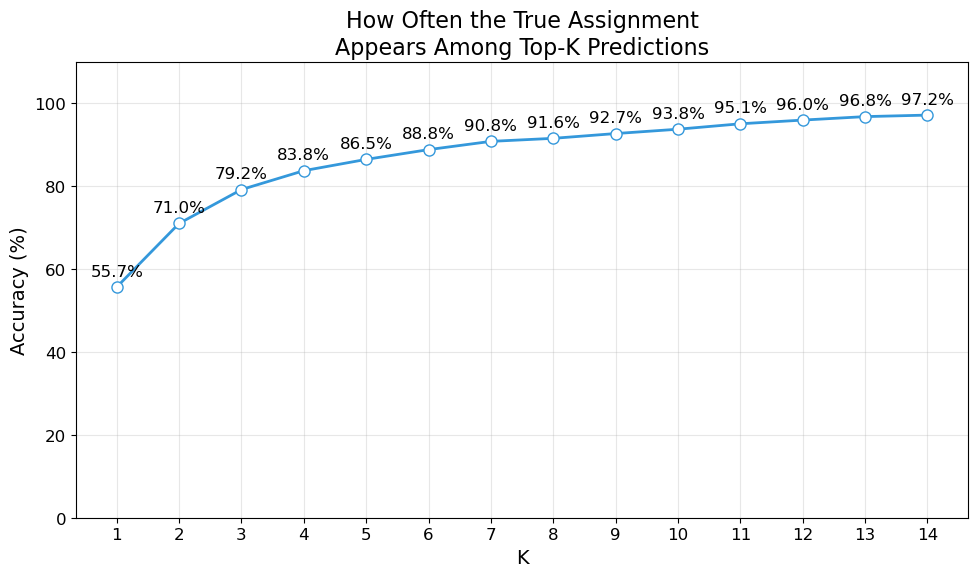

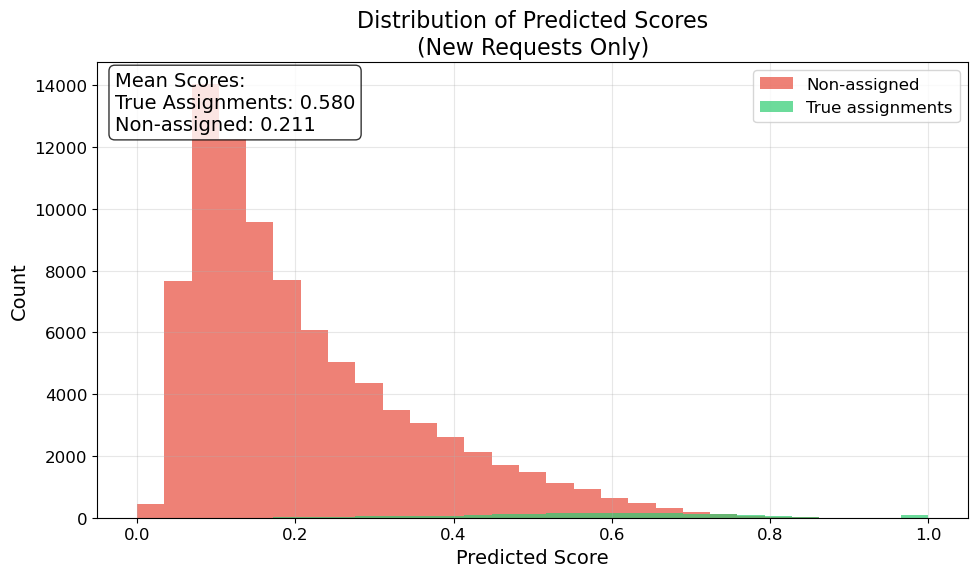

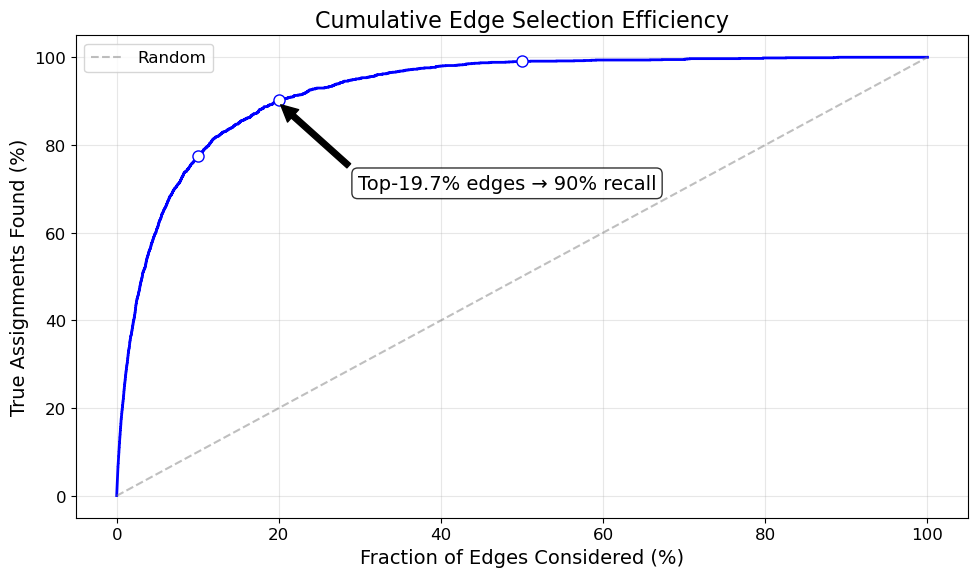

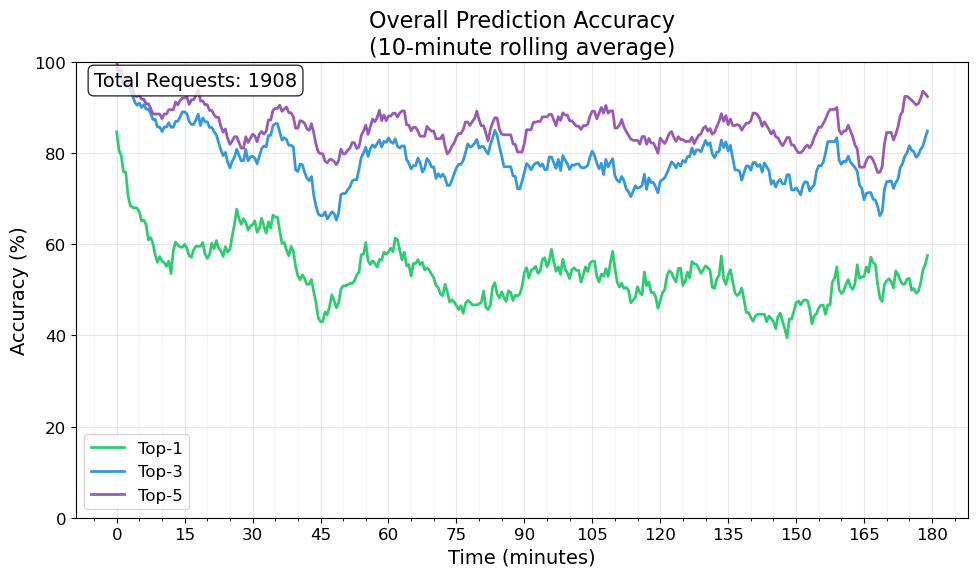

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

=== 2018-11-18 ===


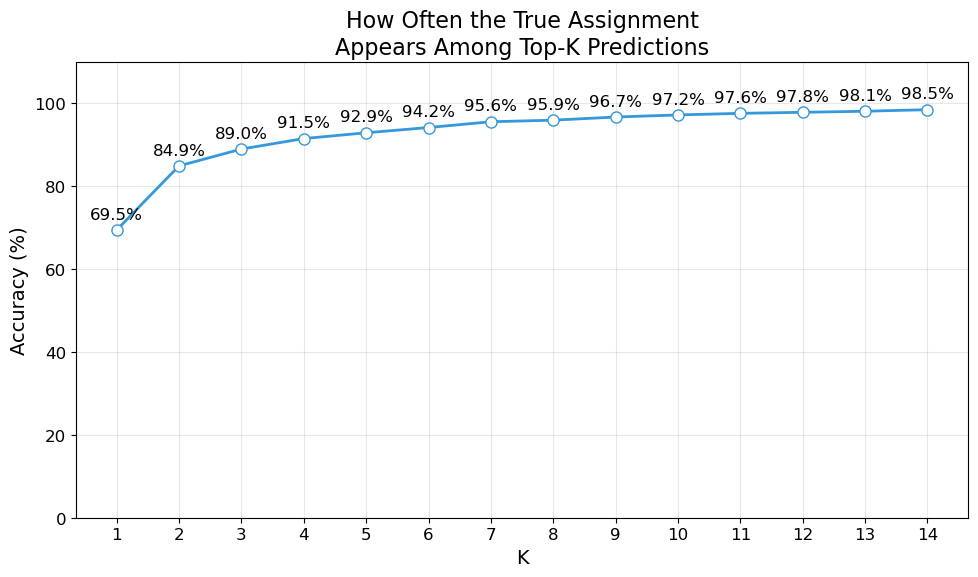

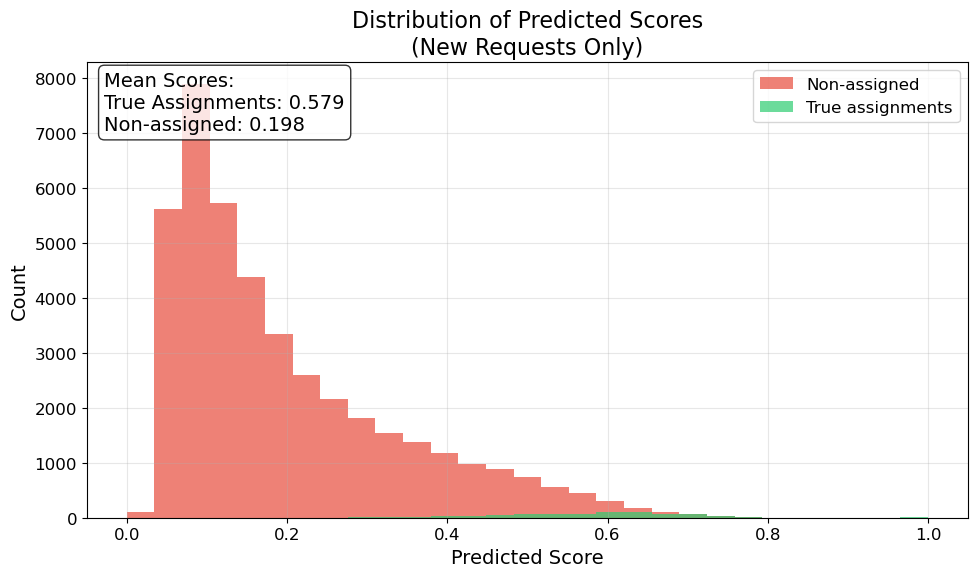

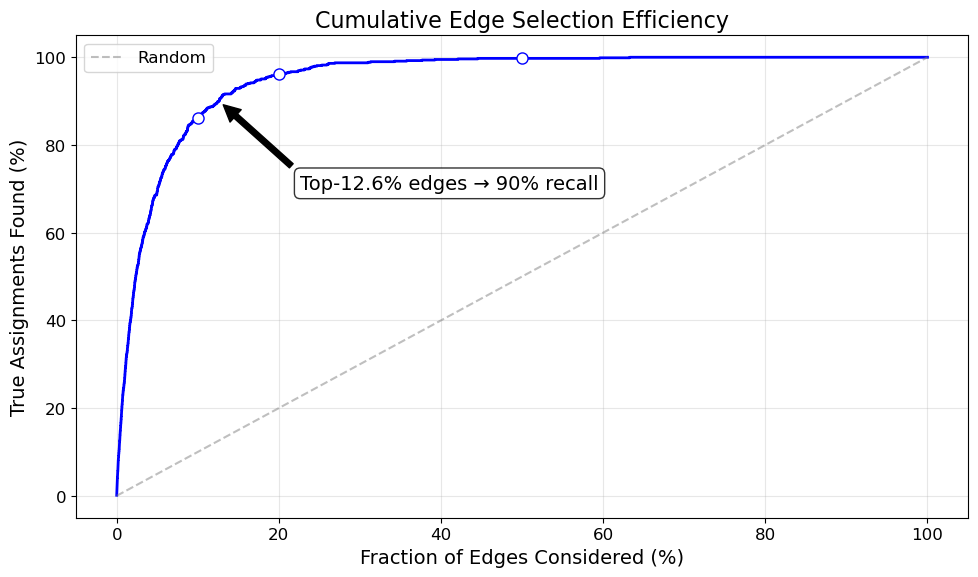

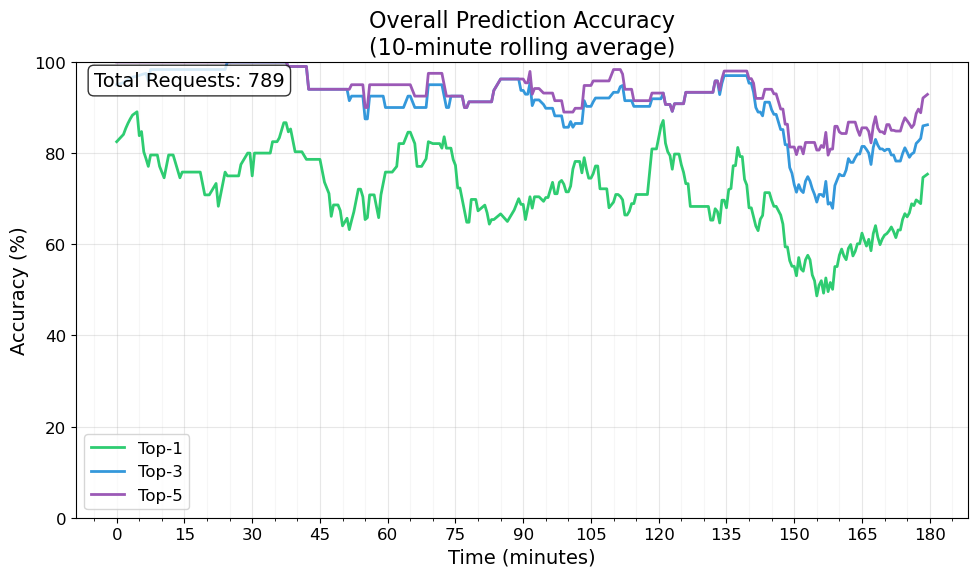

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [10]:
# Analyze model performance on each held-out test day separately.
# Test spans 2 non-adjacent days (11-16, 11-18) concatenated in `data` - analyzing them
# as a single continuous range would treat the day boundary as within-scenario, which
# breaks the "new request" tracking analyze_model_performance relies on.
from gnn_project.analysis.plots import analyze_model_performance
import matplotlib.pyplot as plt
from gnn_project.defaults import *

n_train = masks[TRAIN_MASKS].sum().item()
n_val = masks[VAL_MASKS].sum().item()
test_start = n_train + n_val

test_days = [('2018-11-16', test_start, 360), ('2018-11-18', test_start + 360, 360)]
edge_types = [VR_EDGE_NAME]

for name, start_idx, num_graphs in test_days:
    print(f"=== {name} ===")
    predictions = [get_edge_predictions(data[i], model, device=config.device)
                  for i in range(start_idx, start_idx + num_graphs)]
    figs = analyze_model_performance(data, start_idx, num_graphs, predictions,
                                     edge_types=edge_types, scenario_start_idx=start_idx)
    for fig in figs:
        plt.figure(fig.number)
        plt.show()

In [11]:
# Numeric Top-K accuracy table, computed directly rather than read off the plots above
import pandas as pd
from gnn_project.analysis.plots import _build_request_first_seen_mapping

summary_rows = []
for name, start_idx, num_graphs in test_days:
    req_first_seen = _build_request_first_seen_mapping(data, start_idx, start_idx + num_graphs - 1)
    ranks = []
    for gi in range(start_idx, start_idx + num_graphs):
        graph = data[gi]
        preds = get_edge_predictions(graph, model, device='cpu')[VR_EDGE_NAME]
        edge_index = graph[VR_EDGE_NAME].edge_index
        true_labels = graph[VR_EDGE_NAME].y
        node_ids = graph['request'].node_ids.numpy()
        edges_by_req = {}
        for i in range(edge_index.shape[1]):
            req_idx = edge_index[1, i].item()
            edges_by_req.setdefault(req_idx, []).append((float(preds[i]), bool(true_labels[i].item())))
        for req_idx, edges in edges_by_req.items():
            if req_first_seen.get(node_ids[req_idx], gi) != gi:
                continue  # only new requests
            edges.sort(key=lambda x: x[0], reverse=True)
            true_rank = next((r + 1 for r, (_, is_true) in enumerate(edges) if is_true), None)
            if true_rank is not None:
                ranks.append(true_rank)
    ranks = pd.Series(ranks)
    summary_rows.append({
        'day': name,
        'n_requests': len(ranks),
        'top_1': (ranks <= 1).mean(),
        'top_3': (ranks <= 3).mean(),
        'top_5': (ranks <= 5).mean(),
        'top_10': (ranks <= 10).mean(),
        'mean_rank': ranks.mean(),
    })

pd.DataFrame(summary_rows).set_index('day').style.format({
    'top_1': '{:.1%}', 'top_3': '{:.1%}', 'top_5': '{:.1%}', 'top_10': '{:.1%}', 'mean_rank': '{:.2f}'
})

,n_requests,top_1,top_3,top_5,top_10,mean_rank
day,,,,,,
2018-11-16,1908,55.7%,79.2%,86.5%,93.8%,3.27
2018-11-18,789,69.5%,89.0%,92.9%,97.2%,2.13


In [12]:
for i, graph in enumerate(data):
    edge_type = VR_EDGE_NAME
    # find an true assignment edge and print the graph index to ease visualization
    if graph[edge_type].y.sum().item() > 0:
        print(f"Graph {i} has true assignments.")
        # print the edges with true assignments
        edge_indices = graph[edge_type].edge_index[:, graph[edge_type].y == 1]
        print(f"True assignment edges (source -> target):")
        for src, tgt in edge_indices.t().tolist():
            print(f"{src} -> {tgt}")
        break  # Stop after finding the first graph with true assignments

Graph 0 has true assignments.
True assignment edges (source -> target):
45 -> 20
59 -> 21
88 -> 15
101 -> 22
111 -> 19
157 -> 7
167 -> 1
170 -> 5
186 -> 12
187 -> 8
207 -> 0
213 -> 13
213 -> 2
215 -> 11
223 -> 10
231 -> 14
249 -> 17
268 -> 3
283 -> 16
302 -> 23
306 -> 6
310 -> 18
319 -> 4
328 -> 9
